In [1]:
from os import environ
from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="ERROR", progress=False)

In [2]:
dataset_directory = Path(environ.get("SCARF_DOCS_DATA_DIR", "scarf_datasets"))
dataset_directory.mkdir(parents=True, exist_ok=True)

download_url = (
    "https://datasets.cellxgene.cziscience.com/"
    "3b751975-34bb-409a-a9b7-98380f0450ea.h5ad"
)
h5ad_path = dataset_directory / "binvignat_ra_pbmc.h5ad"
source_store = dataset_directory / "binvignat_ra_pbmc.zarr"

if not h5ad_path.exists():
    partial_path = h5ad_path.with_suffix(".h5ad.part")
    urlretrieve(download_url, partial_path)
    partial_path.replace(h5ad_path)

In [3]:
inspection = scarf.inspect_h5ad(str(h5ad_path))
assert inspection.matrixKey == "raw/X"
assert inspection.integerLike is True
assert (inspection.nCells, inspection.nFeatures) == (108_717, 21_648)
{
    "count matrix": inspection.matrixKey,
    "cells": inspection.nCells,
    "genes": inspection.nFeatures,
    "integer counts": inspection.integerLike,
}

{'count matrix': 'raw/X',
 'cells': 108717,
 'genes': 21648,
 'integer counts': True}

In [4]:
if not source_store.exists():
    with TemporaryDirectory(dir=dataset_directory) as conversion_directory:
        staged_store = Path(conversion_directory) / source_store.name
        reader = scarf.H5adReader.from_inspect(inspection)
        try:
            scarf.H5adToZarr(
                reader,
                zarr_loc=str(staged_store),
                nthreads=4,
                mem_budget="6G",
            ).dump()
        finally:
            reader.h5.close()
        staged_store.replace(source_store)

In [5]:
source = scarf.DataStore(
    str(source_store), default_assay="RNA", min_features_per_cell=0, nthreads=4
)
{"cells": source.cells.N, "genes": source.RNA.feats.N}

{'cells': 108717, 'genes': 21648}

In [6]:
analysis_directory = TemporaryDirectory()
analysis_store = Path(analysis_directory.name) / "ra_batch_demo.zarr"

ds = scarf.mount_datastore(
    str(source_store),
    at=str(analysis_store),
    default_assay="RNA",
    min_features_per_cell=0,
    nthreads=4,
)
{
    "same cell count": ds.cells.N == source.cells.N,
    "same gene count": ds.RNA.feats.N == source.RNA.feats.N,
}

{'same cell count': True, 'same gene count': True}

In [7]:
batch = ds.cells.fetch_all("batch").astype(str)
disease = ds.cells.fetch_all("disease").astype(str)
batch_values = np.unique(batch)
disease_values = np.unique(disease)
assert batch_values.size == 3
assert disease_values.size == 2
pd.crosstab(batch, disease, rownames=["batch"], colnames=["condition"])

condition,normal,rheumatoid arthritis
batch,,
1,19011,21639
2,17989,8043
3,23080,18955


In [8]:
rng = np.random.default_rng(42)
selected = np.zeros(ds.cells.N, dtype=bool)

for batch_value in batch_values:
    for disease_value in disease_values:
        candidates = np.flatnonzero((batch == batch_value) & (disease == disease_value))
        assert candidates.size >= 1_500
        chosen = rng.choice(candidates, size=1_500, replace=False)
        selected[chosen] = True

assert selected.sum() == 9_000
ds.cells.insert(column_name="docs_ra_batch_demo", values=selected, overwrite=True)

pd.crosstab(
    batch[selected], disease[selected], rownames=["batch"], colnames=["condition"]
)

condition,normal,rheumatoid arthritis
batch,,
1,1500,1500
2,1500,1500
3,1500,1500


In [9]:
pipeline_options = {
    "cell_key": "docs_ra_batch_demo",
    "filtering": False,
    "leiden": False,
    "cell_cycle": False,
    "paris": False,
    "doublets": False,
    "markers": False,
    "snapshot_columns": ("batch", "disease", "rough_annot"),
}

In [10]:
uncorrected = ds.pipeline.run(label="ra_uncorrected", **pipeline_options)
{"analysis cells": int(uncorrected.cells.fetch_all("I").sum())}

{'analysis cells': 9000}

In [11]:
harmony = ds.pipeline.run(
    label="ra_harmony", harmony_batch_columns=["batch"], **pipeline_options
)
{"analysis cells": int(harmony.cells.fetch_all("I").sum())}

{'analysis cells': 9000}

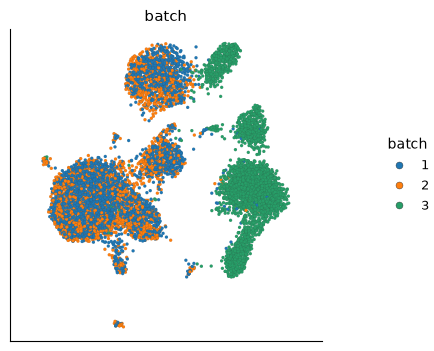

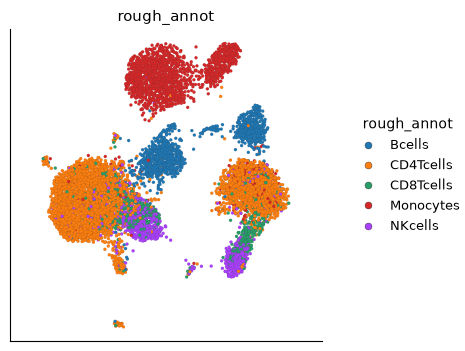

In [12]:
ds.plots.embedding(run=uncorrected, color_by="batch")
ds.plots.embedding(run=uncorrected, color_by="rough_annot")

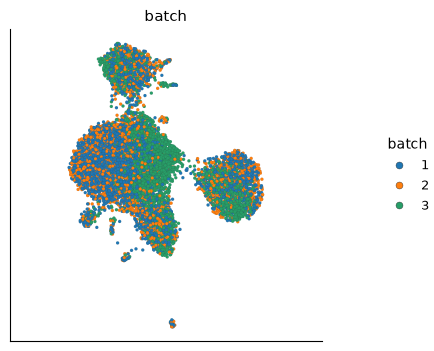

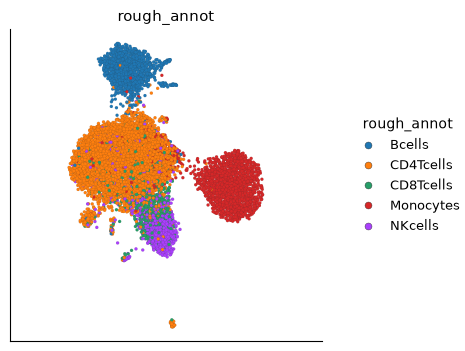

In [13]:
ds.plots.embedding(run=harmony, color_by="batch")
ds.plots.embedding(run=harmony, color_by="rough_annot")

In [14]:
def integration_diagnostics(run):
    return {
        "iLISI (batch)": ds.metric_ilisi(
            batch_colname="batch", neighbors=run["neighbors"]
        ),
        "cLISI (rough_annot)": ds.metric_clisi(
            annotation_column="rough_annot", neighbors=run["neighbors"]
        ),
        "graph connectivity (rough_annot)": ds.metric_graph_connectivity(
            annotation_column="rough_annot", graph=run["connectivity_map"]
        ),
    }

In [15]:
score_frame = pd.DataFrame(
    {
        "Uncorrected": integration_diagnostics(uncorrected),
        "Harmony": integration_diagnostics(harmony),
    }
).T
score_frame.round(3)

,iLISI (batch),cLISI (rough_annot),graph connectivity (rough_annot)
Uncorrected,0.062,0.997,0.948
Harmony,0.205,0.996,0.944
